# 1.- Acceder a los datos y prepararlos para su analisis. 

## Importacion de las librerias necesarias.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

## Importacion de los datos

In [3]:
visits_df = pd.read_csv('visits_log_us.csv')
orders_df = pd.read_csv('orders_log_us.csv')
costs_df = pd.read_csv('costs_us.csv')

## Primer vistazo a los DataFrames

In [4]:
#DataFrame de visitas
print(visits_df.head())
print(visits_df.info())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage

In [5]:
#Convertiremos las columnas "End Ts" y "Start Ts" a fechas
visits_df['End Ts'] = pd.to_datetime(visits_df['End Ts'])
visits_df['Start Ts'] = pd.to_datetime(visits_df['Start Ts'])
print(visits_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB
None


In [6]:
#Buscaremnos valores duplicados en el DataFrame visits_df
visits_df[visits_df.duplicated()]


,Device,End Ts,Source Id,Start Ts,Uid


In [7]:
# DataFrame de ordenes
print(orders_df.head())
print(orders_df.info())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None


In [8]:
#Se convierte la columna 'But Ts' a formato fecha
orders_df['Buy Ts'] = pd.to_datetime(orders_df['Buy Ts'])
print(orders_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
None


In [9]:
#Buscamos filas duplicadas en el DataFrame orders_df
orders_df[orders_df.duplicated()]

,Buy Ts,Revenue,Uid


In [10]:
#DataFrame de costos
print(costs_df.head())
print(costs_df.info())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None


In [11]:
#Convertimos la columna 'dt' a formato de fecha
costs_df['dt'] = pd.to_datetime(costs_df['dt'])
print(costs_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB
None


In [12]:
#Buscando duplicados en el DataFrame costs_df
costs_df[costs_df.duplicated()]

,source_id,dt,costs


# 2.- Informes y calculo de métricas

## DataFrame visitas

### 2.1.1 ¿Cuántas personas lo usan cada día, semana y mes?

In [13]:
#Calculo de visitas por día
visitors_per_day = visits_df.groupby(visits_df['Start Ts'].dt.date)['Uid'].nunique().reset_index()
visitors_per_day.columns = ['date', 'visitors']
visitors_per_day.head()

,date,visitors
0,2017-06-01,605
1,2017-06-02,608
2,2017-06-03,445
3,2017-06-04,476
4,2017-06-05,820


In [14]:
#Promedio de personas que visitan por día
visitors_per_day_mean = '{:.2f}'.format(visitors_per_day['visitors'].mean())
print('Promedio de personas que hacen visitas diarias:', visitors_per_day_mean)

Promedio de personas que hacen visitas diarias: 907.99


In [15]:
#Calculo de visitas por semana
visitors_per_week = visits_df.groupby(visits_df['Start Ts'].dt.to_period('W'))['Uid'].nunique().reset_index()
visitors_per_week.columns = ['date_week', 'visitors']
visitors_per_week.head()


,date_week,visitors
0,2017-05-29/2017-06-04,2021
1,2017-06-05/2017-06-11,4129
2,2017-06-12/2017-06-18,2812
3,2017-06-19/2017-06-25,2878
4,2017-06-26/2017-07-02,3064


In [16]:
#Promedio de visitas por semana
visitors_per_week_mean = '{:.2f}'.format(visitors_per_week['visitors'].mean())
print('Promedio personas que visitan por semana:', visitors_per_week_mean)

Promedio personas que visitan por semana: 5716.25


In [17]:
#Promedio de visitas por mes
visitors_per_month = visits_df.groupby(visits_df['Start Ts'].dt.to_period('M'))['Uid'].nunique().reset_index()
visitors_per_month.columns = ['date_month','visitors']
visitors_per_month.head()

,date_month,visitors
0,2017-06,13259
1,2017-07,14183
2,2017-08,11631
3,2017-09,18975
4,2017-10,29692


In [18]:
#Promedio de visitas por mes
visitors_per_month_mean = '{:.2f}'.format(visitors_per_month['visitors'].mean())
print('Promedio personas que visitan por mes:', visitors_per_month_mean)

Promedio personas que visitan por mes: 23228.42


### 2.1.2 Cantidad de sesiones por día

In [19]:
visits_per_day = visits_df.groupby(visits_df['Start Ts'].dt.date)['Uid'].count().reset_index()
visits_per_day.columns = ['date', 'total_visits']
visits_per_day.head()

,date,total_visits
0,2017-06-01,664
1,2017-06-02,658
2,2017-06-03,477
3,2017-06-04,510
4,2017-06-05,893


In [20]:
#Promedio de visitas por día
visits_per_day_mean = '{:.2f}'.format(visits_per_day['total_visits'].mean())
print('Promedio de visitas diarias:', visits_per_day_mean)

Promedio de visitas diarias: 987.36


## 2.1.3 Duracion de cada sesion

In [21]:
visits_df['session_time'] = visits_df['End Ts'] - visits_df['Start Ts']
visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0 days 00:00:00


In [22]:
print('Tiempo promedio de la duracion de cada visita:', visits_df['session_time'].mean())

Tiempo promedio de la duracion de cada visita: 0 days 00:10:43.025687256


## 2.1.4 Frecuencia con la cual los usuarios vuelven a hacer una visita


In [23]:
#Obtenemos el mes de la primera visita para cada user
first_visit_user = visits_df.groupby('Uid')['Start Ts'].min().reset_index()
first_visit_user.name = 'first_visit_date'
first_visit_user.head()

,Uid,Start Ts
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [24]:
#Añadimos esta columna del primer mes de visita al DataFrame visits_df
added_first_order_month = visits_df.join(first_visit_user, on='Uid')
added_first_order_month.head()

ValueError: columns overlap but no suffix specified: Index(['Start Ts', 'Uid'], dtype='object')

In [ ]:
#Damos formato a la columna "first_visit_date" para visualizarla en formato de año y mes
added_first_order_month['first_visit_date'] = added_first_order_month['first_visit_date'].dt.to_period('M')
added_first_order_month.head()


,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0 days 00:00:00,2017-12


In [ ]:
#Añadimos el año y mes de la visita de cada cliente en la columna "order_month"
added_first_order_month['order_month'] = added_first_order_month['Start Ts'].dt.to_period('M')
added_first_order_month.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date,order_month
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03,2018-05
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0 days 00:00:00,2017-12,2017-12


In [ ]:
#Obtenemos la matriz de retencion entera de clientes que vuelven a visitar la pagina
absolute_visits = added_first_order_month.pivot_table(
    index = 'first_visit_date',
    columns= 'order_month',
    values = 'Uid',
    aggfunc = 'nunique'
)
absolute_visits

order_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
first_visit_date,,,,,,,,,,,,
2017-06,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07,NaN,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0
2017-08,NaN,NaN,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0
2017-09,NaN,NaN,NaN,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0
2017-10,NaN,NaN,NaN,NaN,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0
2017-11,NaN,NaN,NaN,NaN,NaN,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0
2017-12,NaN,NaN,NaN,NaN,NaN,NaN,25268.0,1410.0,960.0,786.0,512.0,481.0
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22624.0,1351.0,890.0,565.0,458.0
2018-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22197.0,1267.0,565.0,446.0


In [ ]:
#Obtendremos la matriz de retencion porcentual
retention = absolute_visits.div(absolute_visits.apply(lambda row: row.dropna().iloc[0], axis=1), axis=0)
retention

order_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
first_visit_date,,,,,,,,,,,,
2017-06,1.0,0.078664,0.053775,0.061392,0.068557,0.071423,0.061015,0.057772,0.052342,0.050833,0.040652,0.044951
2017-07,NaN,1.000000,0.056088,0.051294,0.056164,0.058219,0.048174,0.045358,0.045738,0.038813,0.028615,0.027473
2017-08,NaN,NaN,1.000000,0.076908,0.062862,0.062764,0.050093,0.044004,0.036342,0.039485,0.027895,0.026029
2017-09,NaN,NaN,NaN,1.000000,0.085489,0.069205,0.050706,0.039392,0.037835,0.035860,0.024186,0.022809
2017-10,NaN,NaN,NaN,NaN,1.000000,0.078608,0.052239,0.038958,0.034261,0.032221,0.021365,0.020364
2017-11,NaN,NaN,NaN,NaN,NaN,1.000000,0.078281,0.044113,0.038682,0.033727,0.023415,0.021800
2017-12,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.055802,0.037993,0.031107,0.020263,0.019036
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.059715,0.039339,0.024973,0.020244
2018-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.057080,0.025454,0.020093


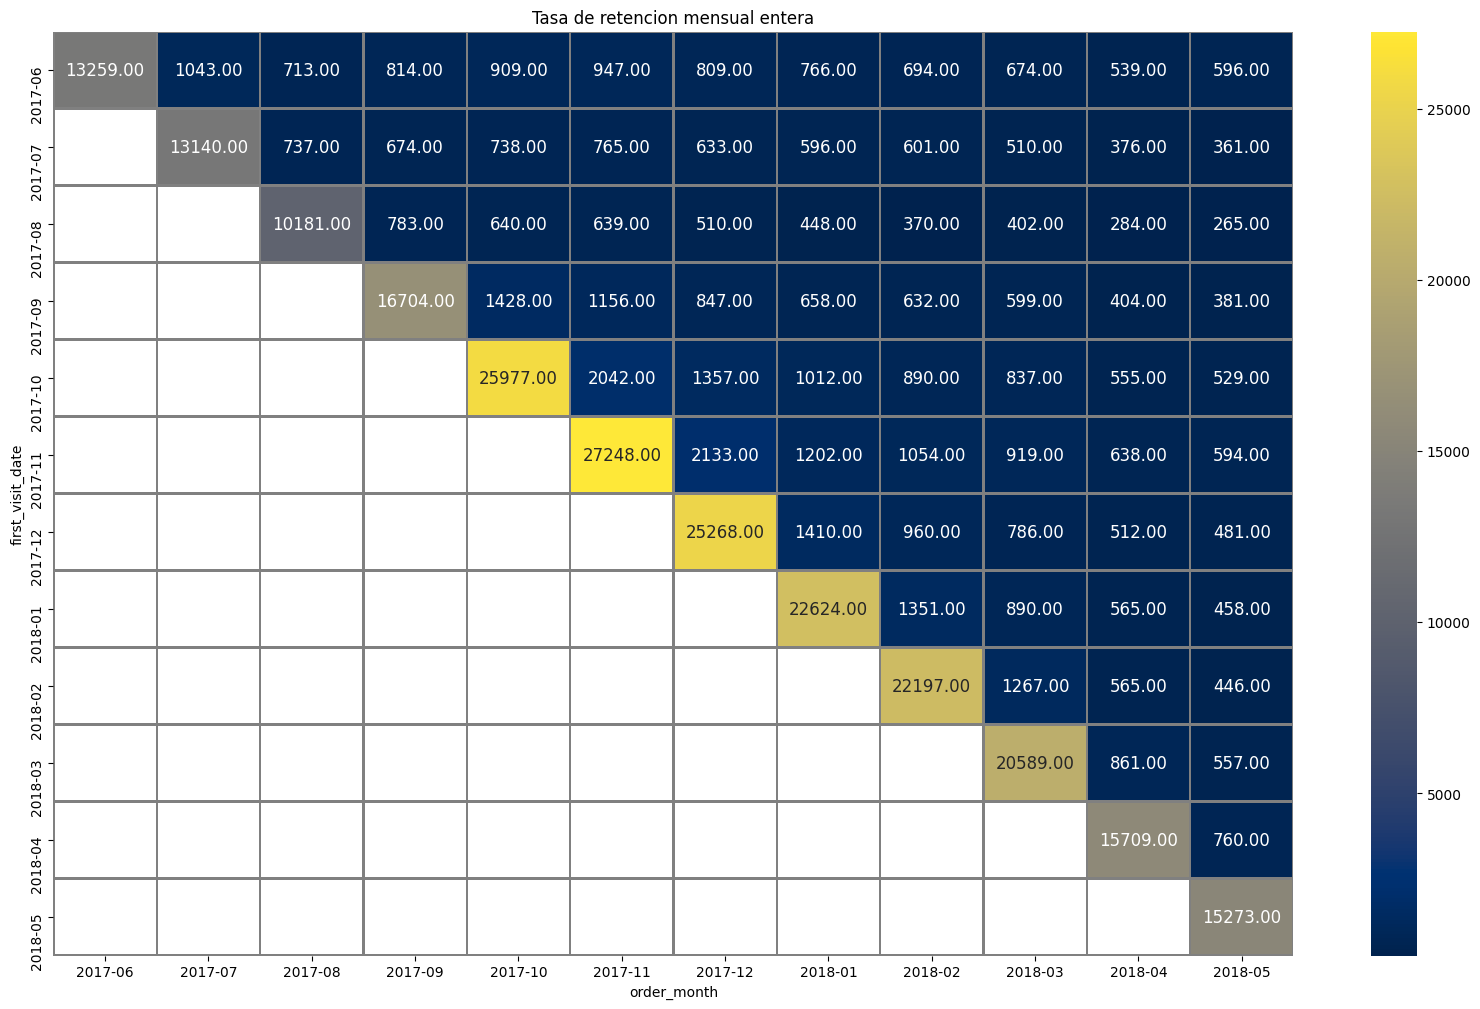

In [ ]:
#Heatmap de la matriz de retencion entera

plt.figure(figsize= (20,12))
plt.title('Tasa de retencion mensual entera')

sns.heatmap(
    data= absolute_visits,
    annot= True,
    fmt='.2f',
    linewidths=1,
    linecolor='gray',
    annot_kws={'size':12},
    cbar=True,
    cmap='cividis'
)



plt.show()


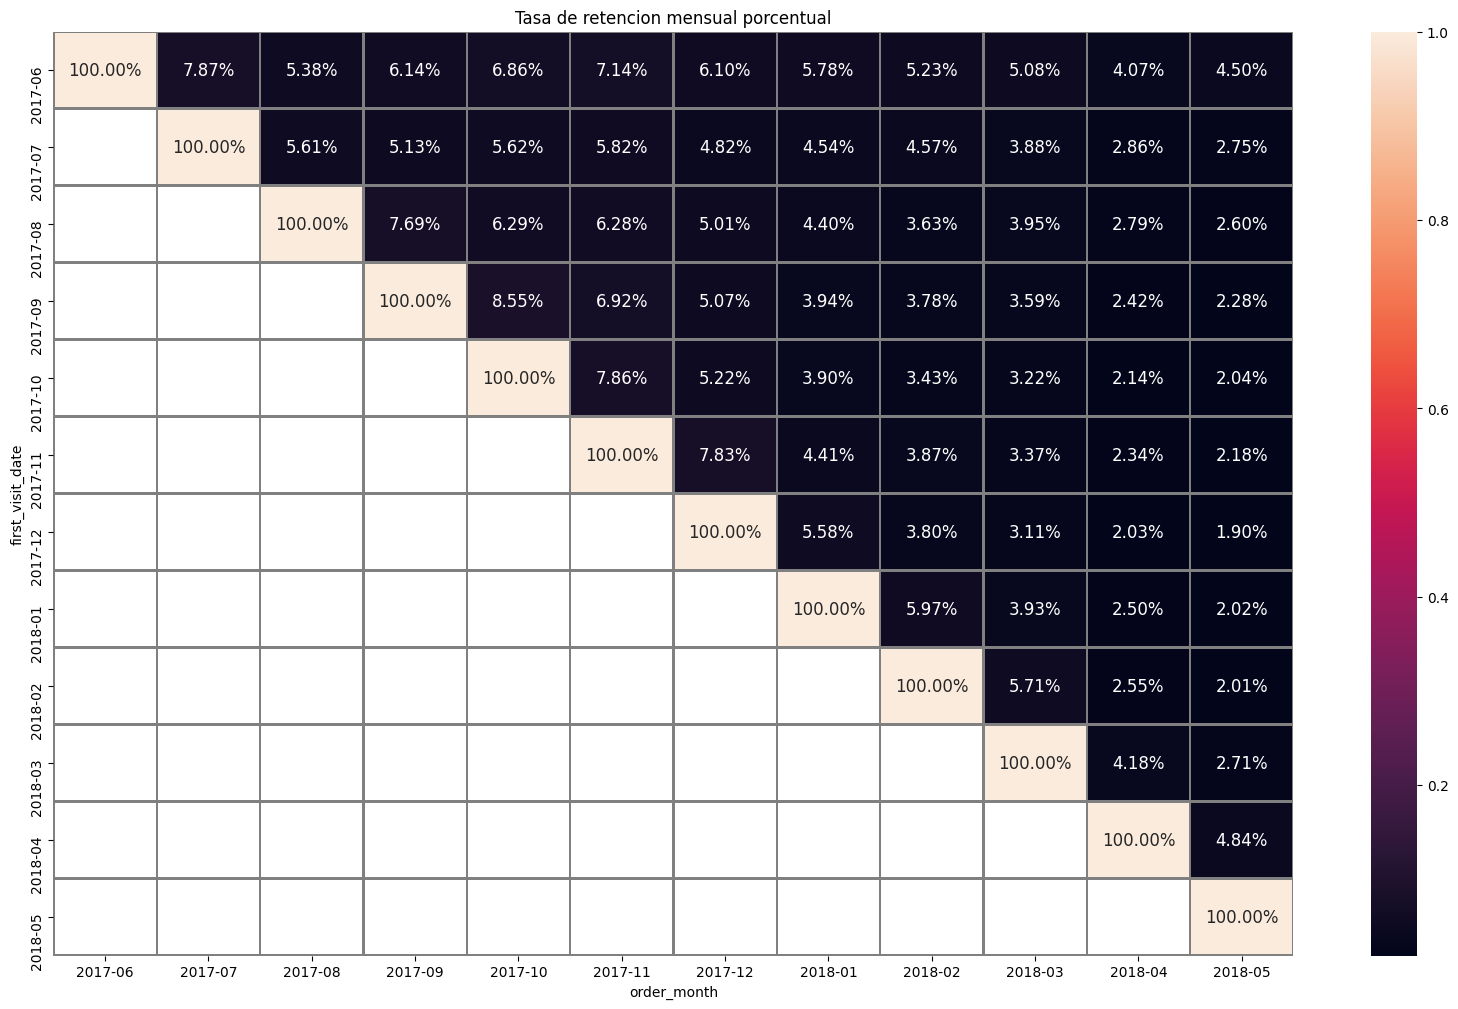

In [ ]:
#Heatmap de la matriz de retencion porcentual
plt.figure(figsize= (20,12))
plt.title('Tasa de retencion mensual porcentual')

sns.heatmap(
    data= retention,
    annot= True,
    fmt='.2%',
    linewidths=1,
    linecolor='gray',
    annot_kws={'size':12},
    cbar=True,
    cmap='rocket'
)



plt.show()


In [25]:
'''
Podemos observar porcentajes relaticvamente bajos en la tasa de retencion mensual (menores al 10%, algunos incluso menores al 5%),
Aunque esto pudiera tambien a picos muy altos en la captacion de nuevos usuarios.
'''

'\nPodemos observar porcentajes relaticvamente bajos en la tasa de retencion mensual (menores al 10%, algunos incluso menores al 5%),\nAunque esto pudiera tambien a picos muy altos en la captacion de nuevos usuarios.\n'

# 2.2 Analisis de ventas

## 2.2.1 ¿Cuando comienza la gente a comprar?

In [77]:
#Obtendremos la fecha de la primera visita y la fecha de la primera compra de cada usuario
#DF con la fecha de la primera visita por usuario
first_visit_user.head()

,Uid,Start Ts
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [78]:
orders_df.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [79]:
#Primera compra de cada usuario
first_order_month = orders_df.groupby('Uid')['Buy Ts'].min()
first_order_month.rename('first_order_month')

Uid
313578113262317        2018-01-03 21:51:00
1575281904278712       2017-06-03 10:13:00
2429014661409475       2017-10-11 18:33:00
2464366381792757       2018-01-28 15:54:00
2551852515556206       2017-11-24 10:14:00
                               ...        
18445147675727495770   2017-11-24 09:03:00
18445407535914413204   2017-09-22 23:55:00
18445601152732270159   2018-03-26 22:54:00
18446156210226471712   2018-02-18 19:34:00
18446167067214817906   2017-10-17 10:16:00
Name: first_order_month, Length: 36523, dtype: datetime64[ns]

In [80]:
#Unimos los DF
convertion = first_visit_user.merge(first_order_month, on='Uid')
convertion.head()

,Uid,Start Ts,Buy Ts
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00


In [81]:
#Cambiamos los nombres de las columans
convertion.columns = ['Uid', 'first_visit', 'first_order']
convertion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Uid          36523 non-null  uint64        
 1   first_visit  36523 non-null  datetime64[ns]
 2   first_order  36523 non-null  datetime64[ns]
dtypes: datetime64[ns](2), uint64(1)
memory usage: 856.1 KB


In [86]:
#Damos formato de AÑO, MES Y DIA a las columnas con fechas
convertion['first_visit'] = pd.to_datetime(convertion['first_visit'])
convertion['first_order'] = pd.to_datetime(convertion['first_order'])
convertion.head()

,Uid,first_visit,first_order
0,313578113262317,2017-09-18,2018-01-03
1,1575281904278712,2017-06-03,2017-06-03
2,2429014661409475,2017-10-11,2017-10-11
3,2464366381792757,2018-01-27,2018-01-28
4,2551852515556206,2017-11-24,2017-11-24


In [87]:
#Nos aseguramos de que todas las ordenes se hayan efectuado el mismo dia, o dias despues de la primera visita
convertion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Uid          36523 non-null  uint64        
 1   first_visit  36523 non-null  datetime64[ns]
 2   first_order  36523 non-null  datetime64[ns]
dtypes: datetime64[ns](2), uint64(1)
memory usage: 856.1 KB


In [88]:
okay_orders = convertion.query("first_visit == first_order or first_visit <= first_order")
okay_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36523 entries, 0 to 36522
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Uid          36523 non-null  uint64        
 1   first_visit  36523 non-null  datetime64[ns]
 2   first_order  36523 non-null  datetime64[ns]
dtypes: datetime64[ns](2), uint64(1)
memory usage: 1.1 MB


In [89]:
#Vemos que no tenemos problemas con las fechas, podemos continuar con el analisis


In [90]:
#Crearemos una columna con la diferencia de dias entre la primer visita y la primer orden
convertion['days_to_first_order'] = (convertion['first_order'] - convertion['first_visit'])
convertion.head()

,Uid,first_visit,first_order,days_to_first_order
0,313578113262317,2017-09-18,2018-01-03,107 days
1,1575281904278712,2017-06-03,2017-06-03,0 days
2,2429014661409475,2017-10-11,2017-10-11,0 days
3,2464366381792757,2018-01-27,2018-01-28,1 days
4,2551852515556206,2017-11-24,2017-11-24,0 days


In [102]:
convertion.loc[convertion['days_to_first_order'] > '30 days', 'category'] = 'Mas de un mes'
convertion.loc[convertion['days_to_first_order'] <=  '30 days', 'category'] = 'Menos de un mes'
convertion.loc[convertion['days_to_first_order'] <=  '7 days', 'category'] = 'Una semana o menos'
convertion.loc[convertion['days_to_first_order'] == '0 days', 'category'] = '0 días'

convertion.head(20)

,Uid,first_visit,first_order,days_to_first_order,category
0,313578113262317,2017-09-18,2018-01-03,107 days,Mas de un mes
1,1575281904278712,2017-06-03,2017-06-03,0 days,0 días
2,2429014661409475,2017-10-11,2017-10-11,0 days,0 días
3,2464366381792757,2018-01-27,2018-01-28,1 days,Una semana o menos
4,2551852515556206,2017-11-24,2017-11-24,0 days,0 días
5,3077748354309989,2018-03-03,2018-03-03,0 days,0 días
6,3605148382144603,2017-08-15,2017-09-21,37 days,Mas de un mes
7,3753586865891862,2018-03-03,2018-03-03,0 days,0 días
8,4808417689019433,2018-01-09,2018-01-09,0 days,0 días
9,4992223027560440,2018-04-04,2018-04-04,0 days,0 días


In [104]:
#Listado del tiempo que tardan los clientes en realizar un pedido.
category_convertion = convertion.groupby('category')['Uid'].count().reset_index()
category_convertion.columns = ['convertion', 'qty']
category_convertion = category_convertion.sort_values(by='qty', ascending=False)
category_convertion.head()

,convertion,qty
0,0 días,25039
1,Mas de un mes,4934
3,Una semana o menos,4297
2,Menos de un mes,2253


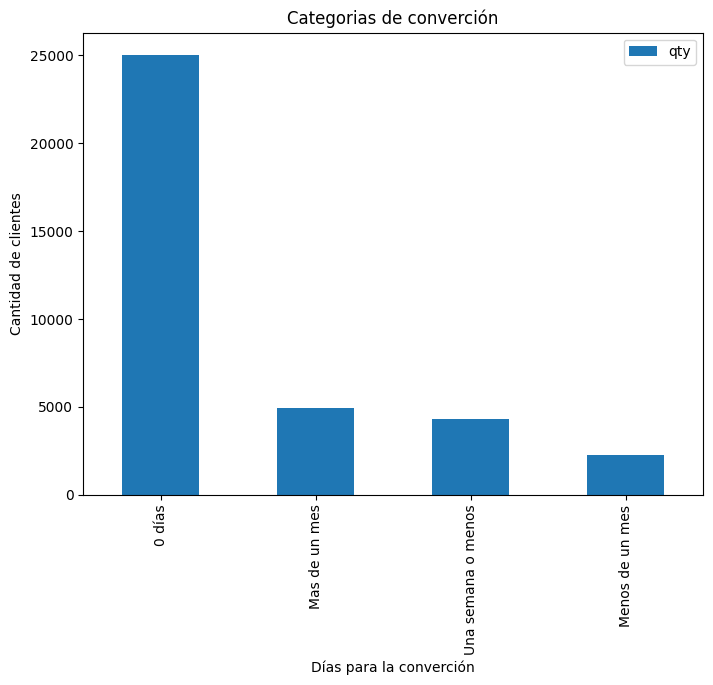

In [105]:
category_convertion.plot(
    kind='bar',
    title='Categorias de converción',
    x='convertion',
    y='qty',
    xlabel = 'Días para la converción',
    ylabel='Cantidad de clientes',
    figsize=(8,6)
)

plt.show()